# Import libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pylab as plt
import seaborn as sns

# Datasets
from sklearn.datasets import load_breast_cancer

# Optimazation
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score

# Model
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from scipy.stats import randint

import optuna

import time

plt.style.use("ggplot")
sns.set_theme()

c:\ML-exploration\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load datasets
data = load_breast_cancer(as_frame=True)
df= data.frame

# Features and target

In [3]:
X = df.drop("target", axis=1)
y = df['target']

# Train-test splits

In [4]:
# stratify=y (Ensures equal class proportions in train and test splits)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Baseline model (Random forest classifier)

In [5]:
start = time.time()
baseline_rf = RandomForestClassifier(random_state=42)
baseline_rf.fit(X_train, y_train)
baseline_rf_time = time.time() - start
baseline_rf_predictions = baseline_rf.predict(X_test)
baseline_rf_accuracy = accuracy_score(y_test, baseline_rf_predictions)

# Cross validation

A cross-validation score is an evaluation metric that measures how well a machine learning model generalizes to unseen data. It is generated by splitting a single dataset into multiple subsets (folds), iteratively training the model on some folds while testing it on others, and averaging the resulting performance scores.

In [6]:
cross_val_score_ = cross_val_score(baseline_rf, X_train, y_train, cv=5, scoring="accuracy")
# cv represents no. of folds

In [7]:
print(cross_val_score_)
print(cross_val_score_.mean())

[0.9625 0.9875 0.9125 1.     1.    ]
0.9725000000000001


# Grid serach

In [8]:
# Grid search
# Define a parameter grid
grid_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4] #  A split will only occur if both resulting
     # branch nodes have at least the number of samples defined by min_samples_leaf.
}

Grid search is a brute-force hyperparameter tuning method used in machine learning. It automatically trains and evaluates a model across an exhaustive set of predefined parameter combinations to find the configuration that yields the highest predictive accuracy.

In [9]:
# Run grid serach
start = time.time()
# cv: The cross-validation strategy, such as cv=5, splitting your training data into 5 folds to ensure the parameters 
# generalize well.
# n_jobs: Sets the number of CPU cores to use. Setting n_jobs=-1 uses all available cores to 
# run evaluations concurrently.
grid = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=grid_params, 
                    cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)
grid_time = time.time() - start

In [11]:
# the best configuration
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
0.9725000000000001


# Randomized Search

In [12]:
# Define parameter distributions.
random_params = {"n_estimators": randint(100,500), "max_depth":randint(3,30), "min_samples_split": randint(2,20),
                 "min_samples_leaf":randint(1,10)}

In [13]:
# Run randomized search
start = time.time()
random_search = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42), param_distributions=random_params,
                                   cv=5, n_iter=5, scoring="accuracy", n_jobs=-1)

In [14]:
random_search.fit(X_train, y_train)
random_time = time.time() - start

In [16]:
# Best results
print(random_search.best_params_)
print(random_search.best_score_)

{'max_depth': 16, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 208}
0.9699683544303799


# Bayesian Optimization with Optuna

Optuna uses Bayesian optimization by default via its Tree-structured Parzen Estimator (TPE) algorithm to efficiently find optimal hyperparameters. 
Unlike brute-force Grid Search or Random Search, Optuna balances exploration and exploitation by learning from past evaluation results.

Study: A management session representing an optimization task (e.g., maximizing accuracy).
Trial: A single evaluation of the objective function with specific hyperparameter inputs.
Objective Function: The custom Python function where we define the model, select the hyperparameters via dynamic choices, and return the score to optimize.

In [17]:
# Create the objective function
def objective (trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth",3,30),
        "min_samples_split": trial.suggest_int ("min_samples_split",2,20),
        "min_samples_leaf": trial.suggest_int ("min_samples_leaf", 1, 10),
        "random_state":42
    }
    model = RandomForestClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv = 5, scoring = "accuracy").mean()
    return score

In [18]:
# Run the optimization
start = time.time()
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)
optuna_time = time.time() - start

[I 2026-07-07 16:25:23,737] A new study created in memory with name: no-name-d1644abe-9012-4312-bd21-681ae427a8ae
[I 2026-07-07 16:25:24,490] Trial 0 finished with value: 0.9624367088607595 and parameters: {'n_estimators': 182, 'max_depth': 14, 'min_samples_split': 13, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.9624367088607595.
[I 2026-07-07 16:25:26,168] Trial 1 finished with value: 0.9624367088607595 and parameters: {'n_estimators': 403, 'max_depth': 14, 'min_samples_split': 3, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.9624367088607595.
[I 2026-07-07 16:25:27,896] Trial 2 finished with value: 0.9624367088607595 and parameters: {'n_estimators': 396, 'max_depth': 9, 'min_samples_split': 12, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.9624367088607595.
[I 2026-07-07 16:25:28,849] Trial 3 finished with value: 0.9649367088607594 and parameters: {'n_estimators': 200, 'max_depth': 14, 'min_samples_split': 7, 'min_samples_leaf': 5}. Best is trial 3 with valu

In [19]:
# Best results
print(study.best_params)
print(study.best_value)

{'n_estimators': 312, 'max_depth': 24, 'min_samples_split': 2, 'min_samples_leaf': 1}
0.9725000000000001


Bayesian optimization uses information from previous trials to guide future searches.

# Compare Optimization Strategies

In [29]:
# Compare Optimization Strategies
comparison = pd.DataFrame({
    "Method":["Baseline RF", "Grid Search", "Random Search","Optuna"], 
    "Model Accuracy": [baseline_rf_accuracy, grid.best_score_, random_search.best_score_, study.best_value],
    "Training time (s)": [baseline_rf_time, grid_time, random_time, optuna_time]
})
comparison

,Method,Model Accuracy,Training time (s)
0,Baseline RF,0.935673,0.084373
1,Grid Search,0.972500,23.848810
2,Random Search,0.969968,3.261594
3,Optuna,0.972500,36.325929


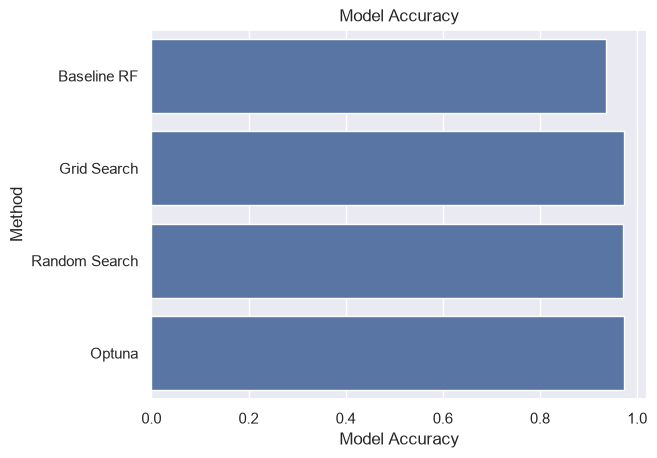

In [30]:
# Visualize results
sns.barplot(data=comparison, x="Model Accuracy", y="Method")
plt.title("Model Accuracy")
plt.show()

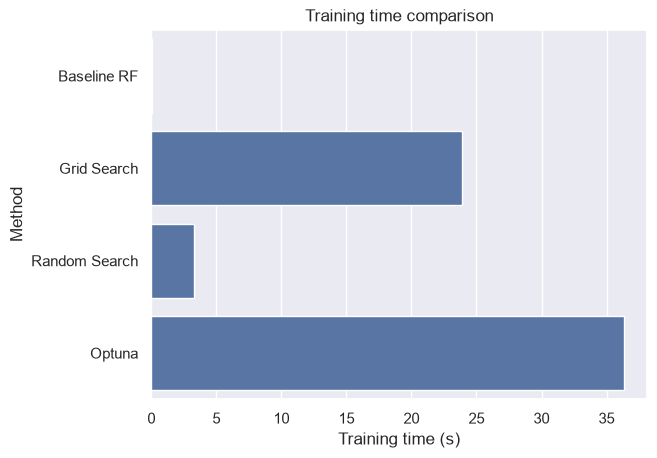

In [32]:
# Training time comparison
sns.barplot(data=comparison, x="Training time (s)", y="Method")
plt.title("Training time comparison")
plt.show()

# Train the best model

The best model is grid search

In [33]:
best_model = RandomForestClassifier(**grid.best_params_, random_state=42)
best_model.fit(X_train, y_train)
predicts = best_model.predict(X_test)

# Evaluate the best model

In [34]:
print(confusion_matrix(y_test, predicts))

[[ 58   6]
 [  4 103]]


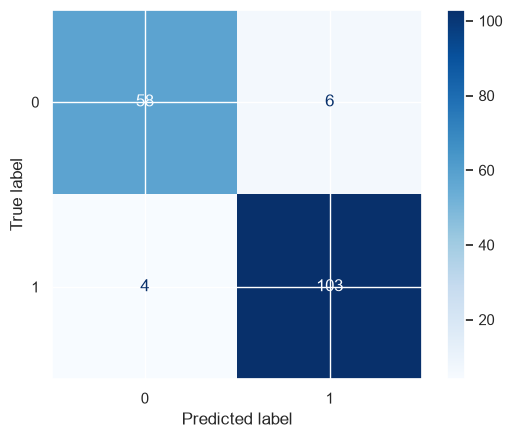

In [36]:
ConfusionMatrixDisplay.from_estimator(best_model,X_test, y_test, cmap="Blues")
plt.show()

# Feature importance

In [37]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

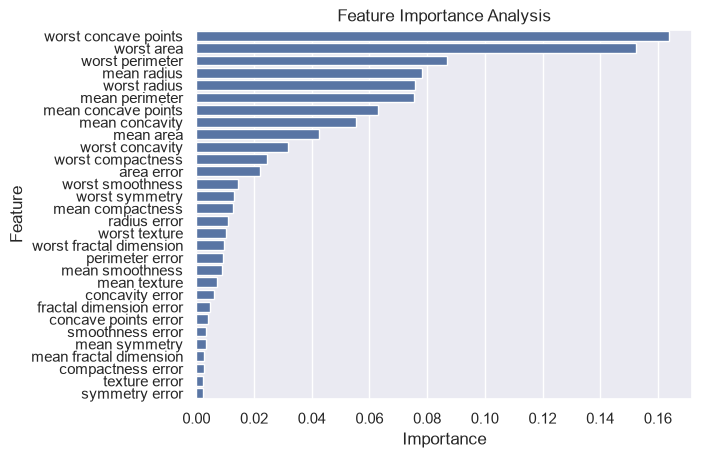

In [38]:
sns.barplot(data=importance, x= "Importance", y="Feature")
plt.title("Feature Importance Analysis")
plt.show()

# Optimization Strategy Comparison

1. Grid Search:
    i) Advantagea - Exhaustive search, simple to understand
    ii) Limitations - Slow as the search space grows
2. Random Search:
    i) Advantages - Faster, explores more combinations
    ii) Limitations - May miss the absolute best parameters
3. Bayesian Optimization (Optuna):
    i) Advantages - Efficient, learns from previous trials
    ii) Limitations - Requires an additional library and tuning budget. Slow as the search space grows


# Practical Recommendations

| Scenario                    | Recommended Method |
| --------------------------- | ------------------ |
| Small search space          | Grid Search        |
| Large search space          | Randomized Search  |
| Expensive models            | Optuna             |
| Production model tuning     | Optuna             |
| Quick baseline optimization | Randomized Search  |
